# Full Bayesian Operator Inference: Compressible Euler

**Workflow:**
1. Generate training data and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    build_bayesian_opinf_model,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    plot_gp_fit,
    plot_full_order_error,
    Plotter,
    run_diagnostics,
    DataScaler,
)
import config
from config import Basis
from euler_plotter import EulerPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"         # OpInf operator structure (no inputs)
NUM_MODES = 6             # POD modes to retain

# Data generation settings
TRAINING_SPAN = (0, 0.08)  # Subset of time domain for training
NUM_SAMPLES = 250           # Number of training samples
NOISE_LEVEL = 0.03        # Noise level for training data
NUM_EVAL_POINTS = 400 # Set to None to use the original training times (no densification)

# Data scaling
USE_SCALED_DATA = False    # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
RUN_MCMC = False           # More expensive, optional
USE_SVI_FOR_MCMC_INIT = False  # Initialize MCMC from SVI result (requires RUN_SVI=True)
GUIDE = numpyro.infer.autoguide.AutoDelta  # Guide for SVI; ignored if not using SVI


# Hyperparameters
GAMMA = 5e1     # Operator prior variance
GAMMA2 = 5e1     # ODE constraint stiffness

## 2. Generate Training Data

In [3]:
# Generate training data using the standard pipeline
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")

generating training data...done in 0.82 s.
Full time domain: (401,)
True states: (600, 401)
Sampled times: (250,)
Sampled snapshots: (600, 250)


In [4]:
# Fit POD basis
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (6, 250)
Cumulative energy: 88.2756%


In [5]:
# Data is already sampled via generate_trajectory
print(f"Training samples: {time_sampled.shape[0]}")
print(f"Training time span: [{time_sampled[0]:.4f}, {time_sampled[-1]:.4f}]")

# Set up evaluation time domains for plotting
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(0, TRAINING_SPAN[-1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(0, time_domain_full[-1], NUM_REGRESSION_POINTS)

# Compress full states for prediction comparison
full_states_compressed = basis.compress(true_states)
print(f"Full states compressed shape: {full_states_compressed.shape}")

Training samples: 250
Training time span: [0.0000, 0.0800]
Full states compressed shape: (6, 401)


## 3a. Data Scaling (Optional)

When `USE_SCALED_DATA=True`, each POD mode is standardized to zero mean and unit variance before GP fitting. This improves GP hyperparameter learning and numerical conditioning.

The scaling is handled consistently:
1. GPs are fitted on scaled data
2. In the Bayesian model: latent states live in scaled space → transformed to original for operator dynamics → derivatives scaled back for comparison with GP derivatives
3. Posterior predictions are inverse-transformed back to original space

In [6]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling disabled: using raw POD coefficients


## 3. Grid Search for Prior Operator

In [7]:
# Find best deterministic operator via regularization grid search
result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=time_sampled,
    snapshots_sampled=snapshots_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=None,
    input_func=None,
    verbose=True
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")

Testing 12 regularization values...
  reg=1.0e-08: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=1.0e-04: UNSTABLE
  reg=1.0e-02: UNSTABLE
  reg=1.0e-01: UNSTABLE
  reg=5.0e-01: UNSTABLE
  reg=1.0e+00: UNSTABLE
  reg=5.0e+00: UNSTABLE
  reg=1.0e+01: UNSTABLE
  reg=1.0e+02: STABLE, error=1.384566
  reg=1.0e+03: STABLE, error=1.403287
  reg=1.0e+04: STABLE, error=1.403563

✅ Best reg: 1.0e+02, error: 1.384566

Prior operator shape: (6, 28)


Stable training solves: 3/3
Stable prediction solves: 3/3


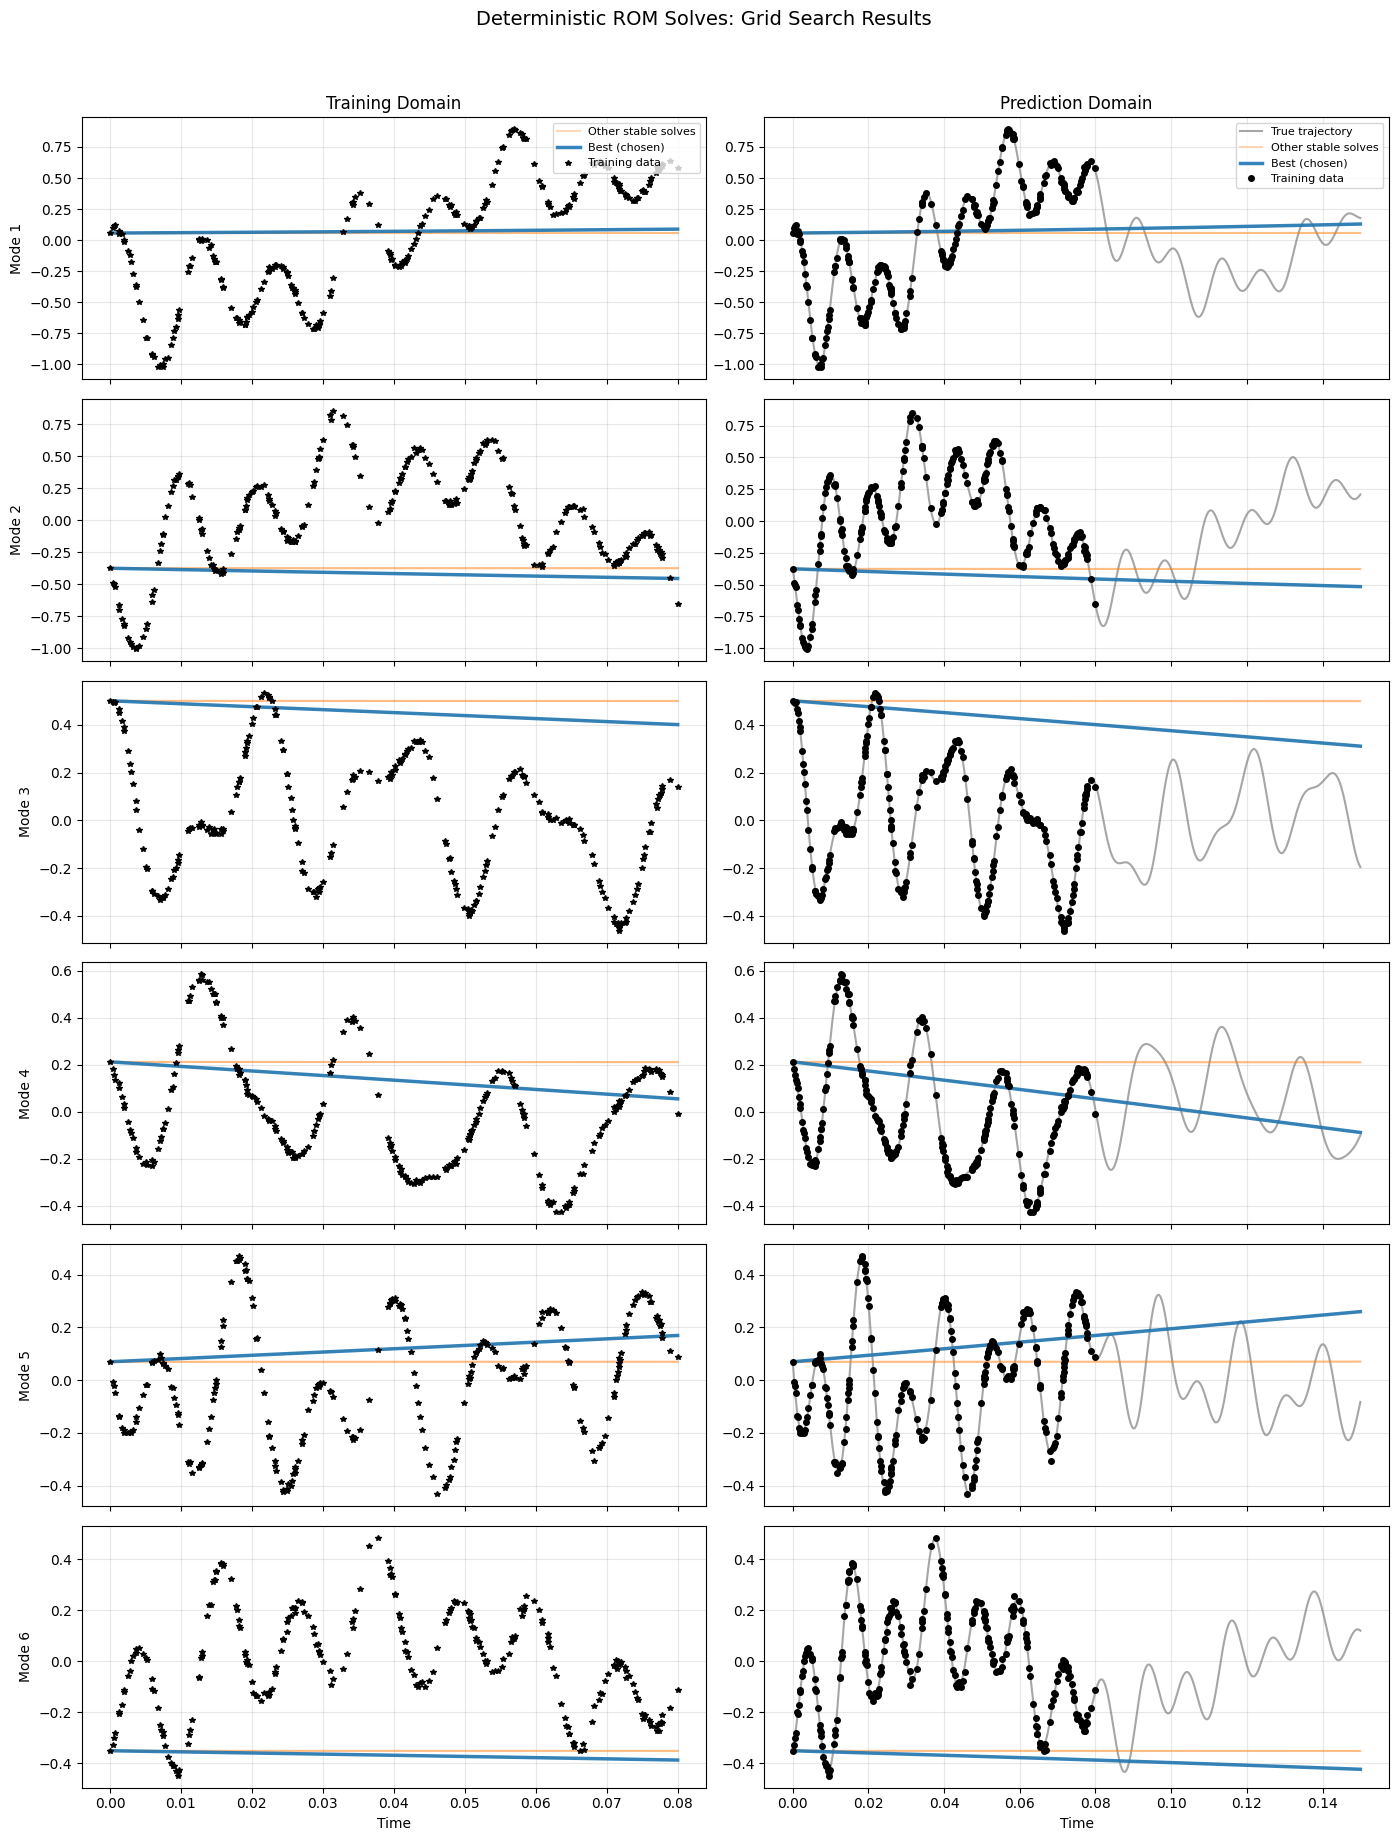

In [8]:
# Debug: Plot all stable deterministic ROM solves from grid search
fig, axes = plot_deterministic_rom_solves(
    grid_search_result=result,
    snapshots_compressed=snapshots_comp_sampled,
    time_sampled=time_sampled,
    time_eval_training=time_domain_eval_training,
    time_eval_prediction=time_domain_eval_prediction,
    time_full=time_domain_full,
    true_states_compressed=full_states_compressed,
)
plt.show()

## 4. Fit GP Hyperparameters

In [9]:
# Fit GP for each mode via MLE (on scaled data if enabled)
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=True
)

Fitting GP hyperparameters via MLE...
  L=0.0049, V=0.5999, N=0.000188
  Mode 0: L=0.0049, V=0.5999, N=0.000188
  L=0.0047, V=0.5568, N=0.000186
  Mode 1: L=0.0047, V=0.5568, N=0.000186
  L=0.0049, V=0.2287, N=0.000064
  Mode 2: L=0.0049, V=0.2287, N=0.000064
  L=0.0053, V=0.1525, N=0.000073
  Mode 3: L=0.0053, V=0.1525, N=0.000073
  L=0.0049, V=0.4073, N=0.000080
  Mode 4: L=0.0049, V=0.4073, N=0.000080
  L=0.0042, V=0.1324, N=0.000156
  Mode 5: L=0.0042, V=0.1324, N=0.000156


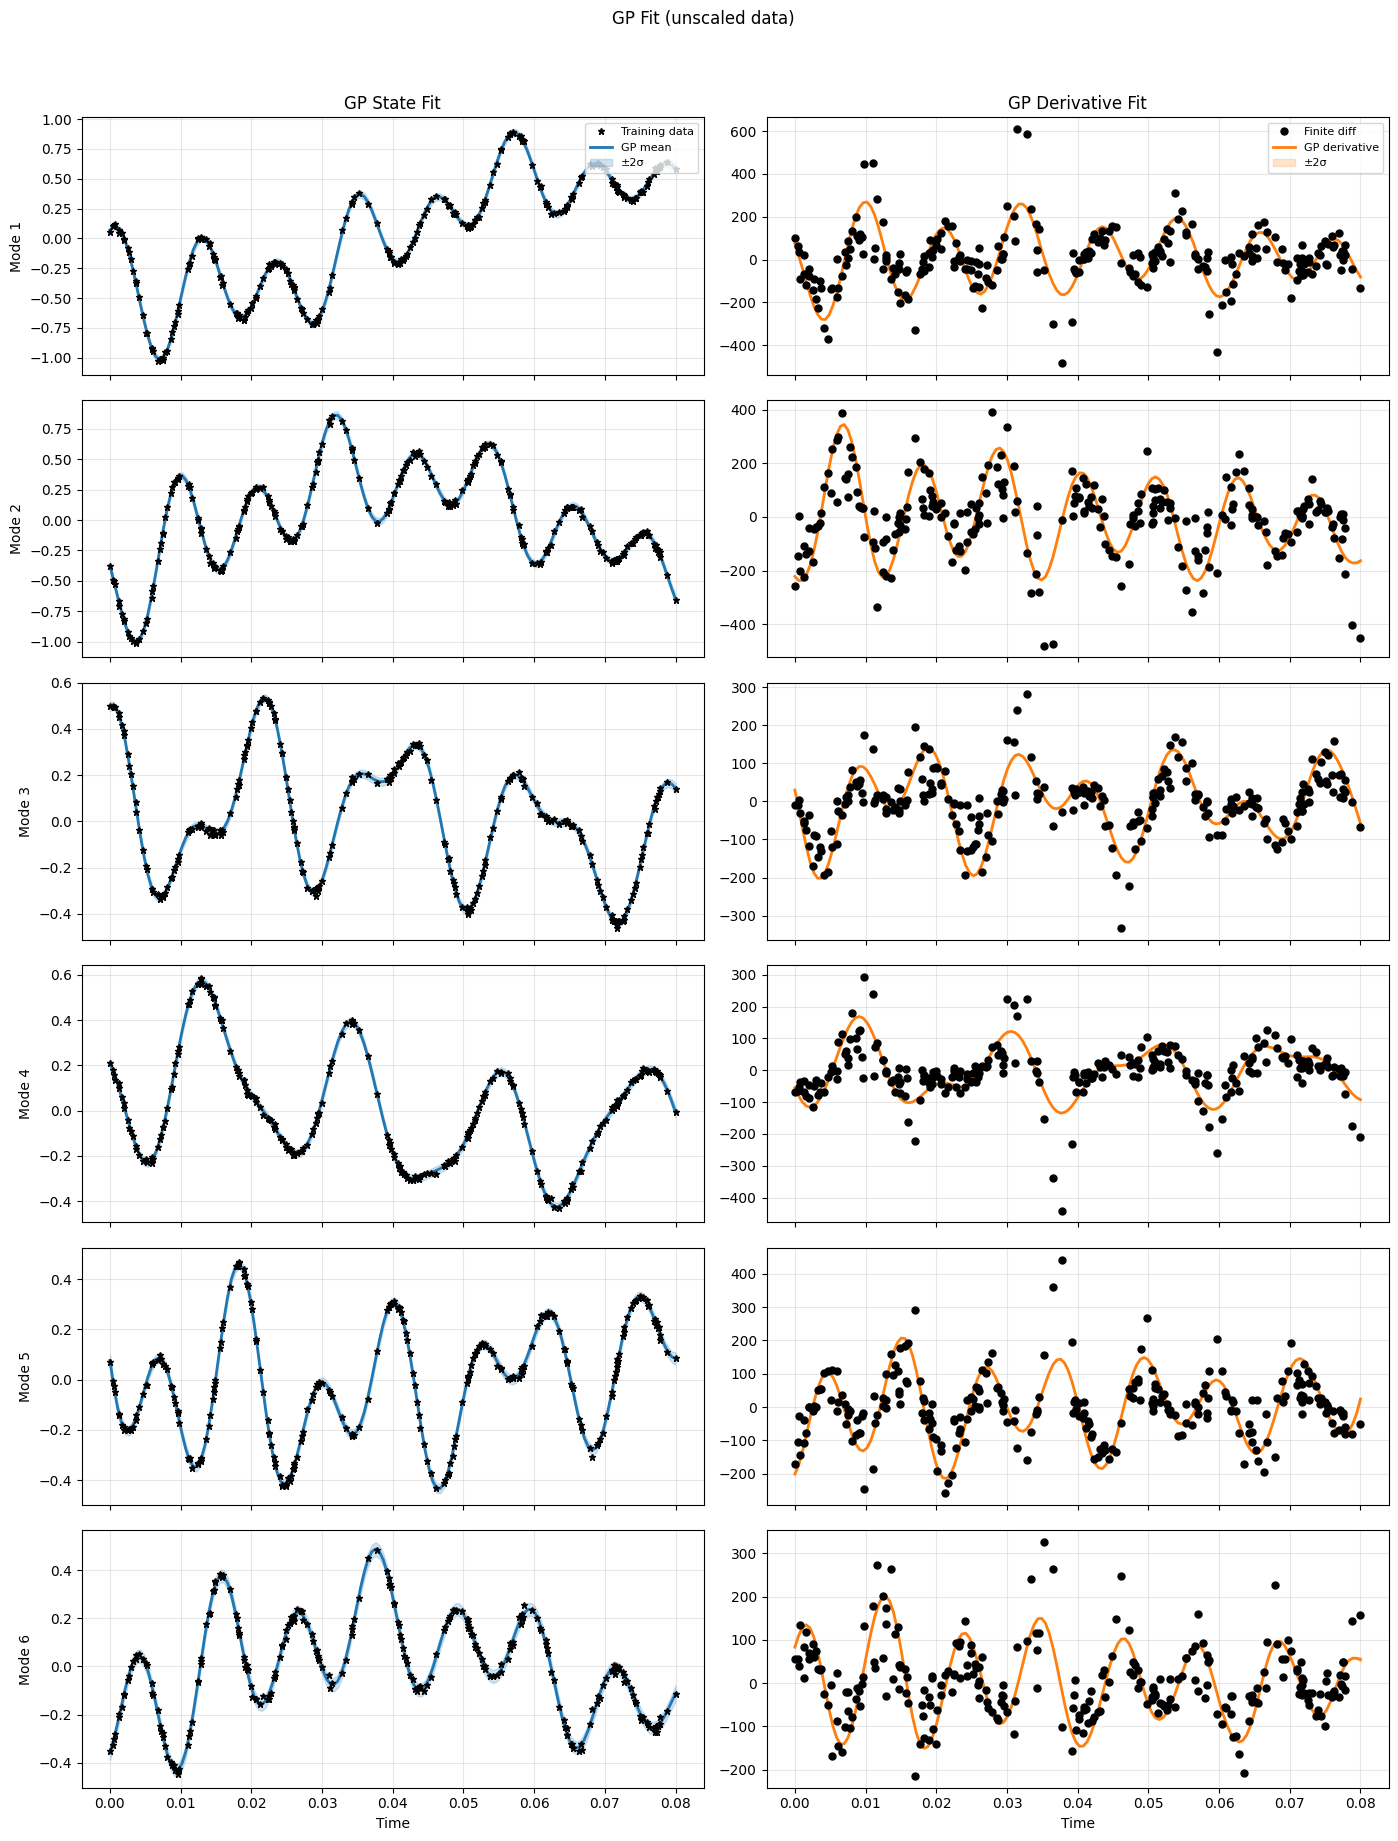

In [10]:
# Visualize GP fit quality (states and derivatives)
# Note: GP models were fitted on training_data (scaled if USE_SCALED_DATA)
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=training_data,
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
)
plt.suptitle(f"GP Fit ({'scaled' if USE_SCALED_DATA else 'unscaled'} data)", y=1.02)
plt.show()

## 5. Bayesian Inference

In [11]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {len(time_sampled)} training samples)")
else:
    time_eval = time_sampled
    print(f"No densification: evaluating at {len(time_sampled)} training times")

# Precompute GP mean predictions at evaluation points
Xs_means = np.array([
    gp_models[i].predict(time_eval[:, None], return_std=False)
    for i in range(NUM_MODES)
])

# Build Bayesian model using shared factory function
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=jnp.zeros_like(prior_operator),
    rom=rom,
    Ls_means=Ls,
    Vs_means=Vs,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    Xs_means=Xs_means,
    Ns_means=Ns,
    inputs_eval=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
)

GP densification: evaluating ODE constraints at 400 points (vs 250 training samples)


Running SVI (gamma=50.0, gamma2=50.0)...


100%|██████████| 50000/50000 [18:48<00:00, 44.32it/s, init loss: 148041.9688, avg. loss [47501-50000]: 8031.9521] 


✅ SVI complete! Final loss: 8028.1177
   Sample keys: ['O', 'X0', 'X1', 'X2', 'X3', 'X4', 'X5']
SVI operator extracted from key 'O', shape: (6, 28)


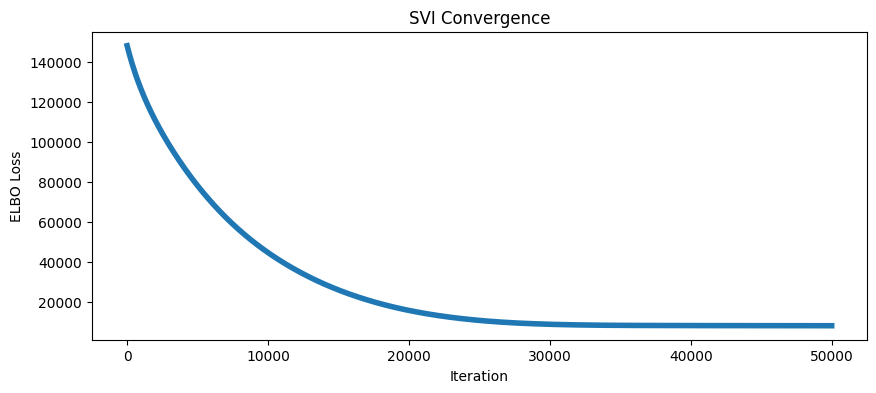

In [12]:
# Run SVI
if RUN_SVI:
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=50000,
        learning_rate=1e-2,
        verbose=True,
        guide=GUIDE
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

In [13]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")
    
    mcmc_result = run_mcmc(
        model=bayesian_opinf_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_warmup=500,
        num_samples=500,
        num_chains=2,
        verbose=True
    )
    samples = mcmc_result.samples

## 6. Results and Visualization

In [14]:
# Check sample keys (debug)
print("Sample keys:", list(samples.keys())[:5], "...")
print()

# Generate ROM predictions from posterior (no input_func for Euler)
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples,
    rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_eval,
    num_modes=NUM_MODES,
    num_pulls=200,
    input_func=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None
)

print(f"Collected {len(Os)} operator samples")
print(f"Stable ROM solves: {len(rom_solves)}")

Sample keys: ['O', 'X0', 'X1', 'X2', 'X3'] ...

Collected 200 operator samples
Stable ROM solves: 200


In [15]:
# Operator posterior summary
O_mean = Os.mean(axis=0)
O_std = Os.std(axis=0)

print("Prior operator (first row):")
print(prior_operator[0, :5])
print("\nPosterior mean (first row):")
print(O_mean[0, :5])
print("\nPosterior std (first row):")
print(O_std[0, :5])

Prior operator (first row):
[ 0.62371559  0.56295147  0.4600706  -0.37939368 -0.66656454]

Posterior mean (first row):
[  6.648205    4.7730846 244.88254    40.05175   103.18169  ]

Posterior std (first row):
[1.5735626e-05 7.6293945e-06 4.1198730e-04 3.4332275e-05 1.6021729e-04]


(200, 6, 28) (1000, 6, 400)
(200, 6, 150) (200, 6, 150)


<Figure size 640x480 with 0 Axes>

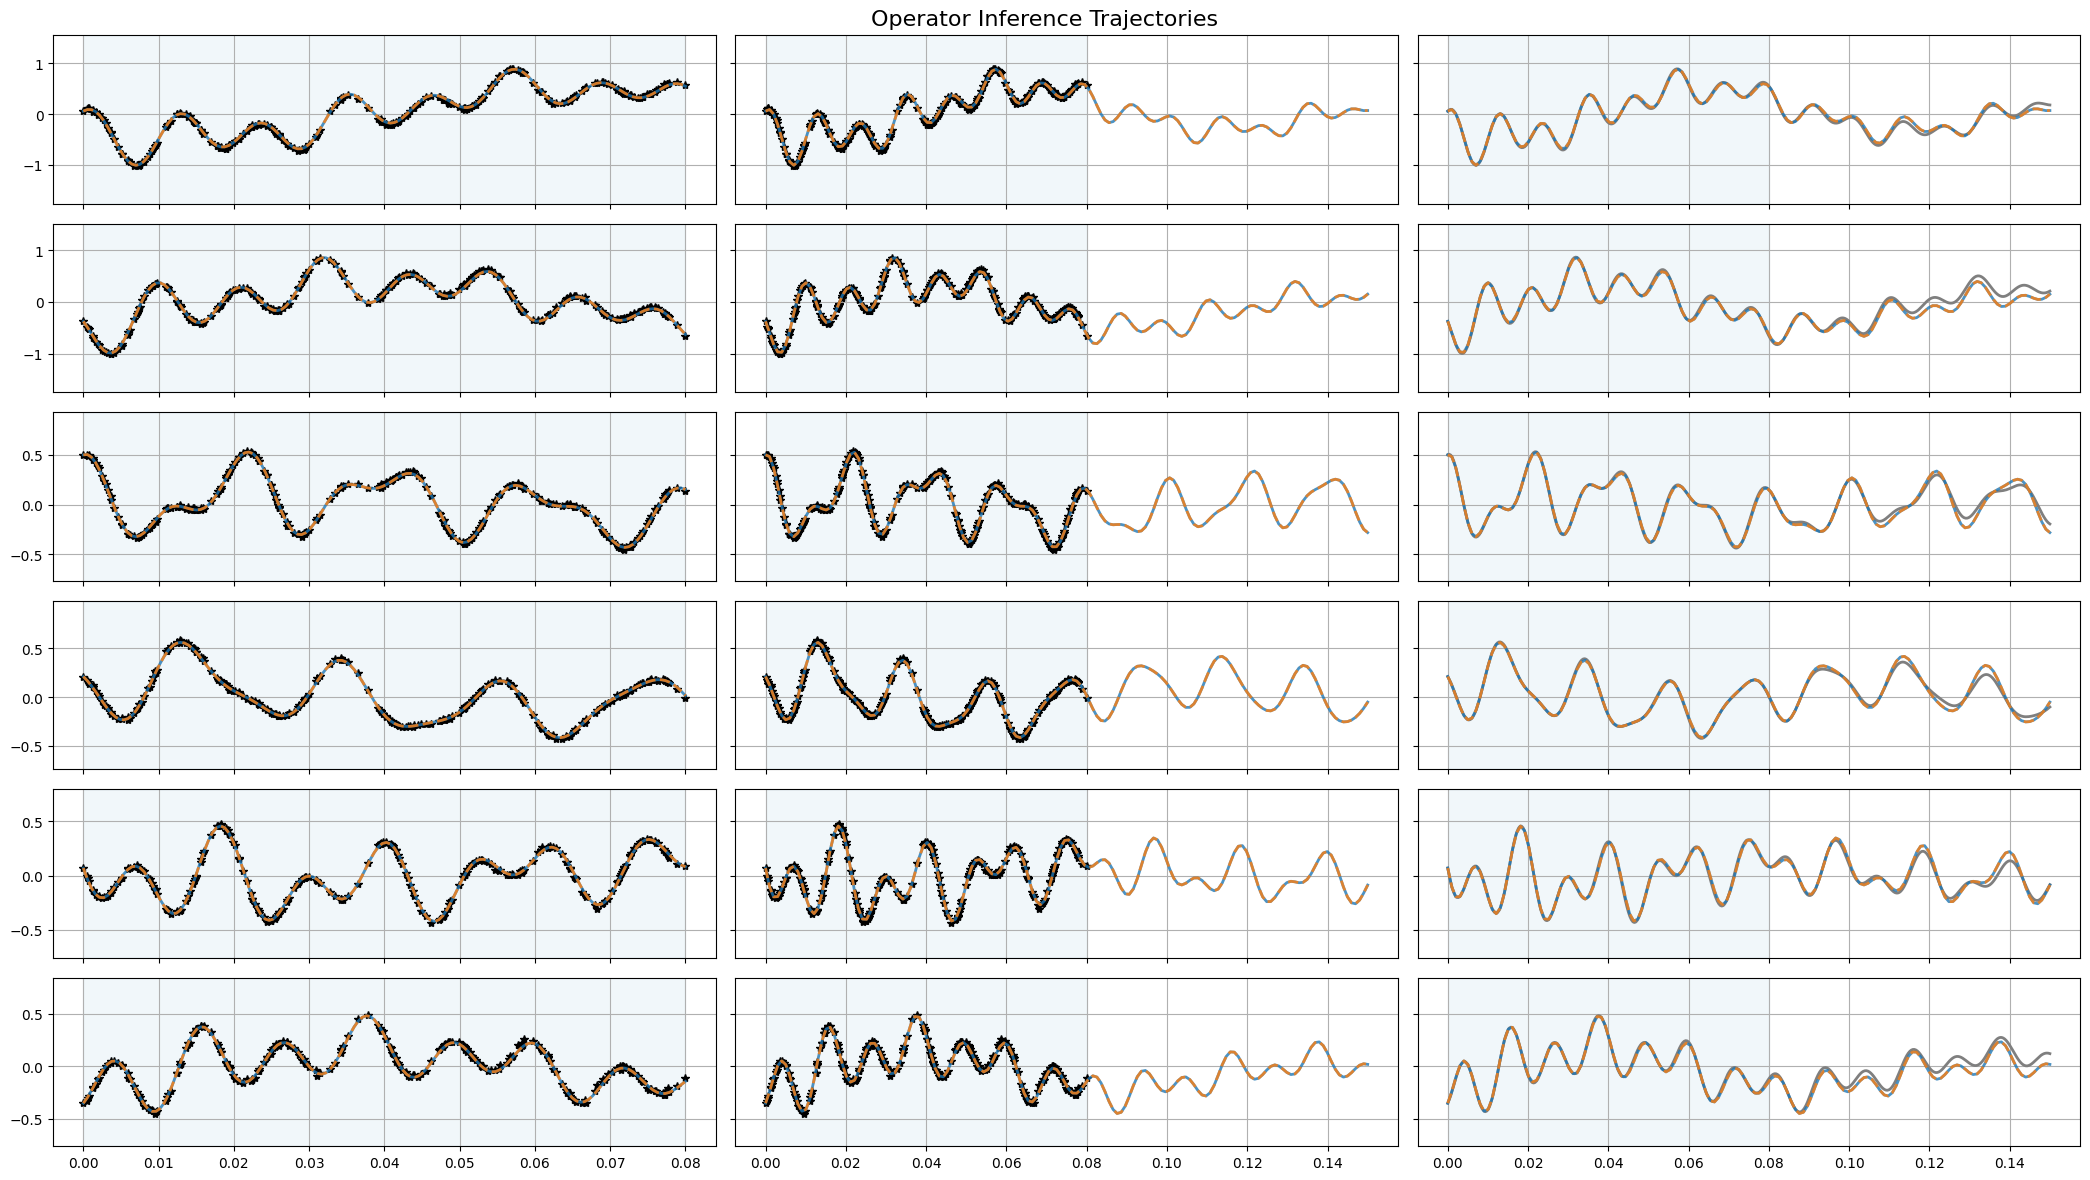

In [16]:
# State reconstruction using EulerPlotter (like backup notebook)
import importlib
import euler_plotter
importlib.reload(euler_plotter)

plotter = euler_plotter.EulerPlotter(
    numPODmodes=NUM_MODES,
    time_domain_training=time_sampled, 
    time_domain_prediction=time_domain_full, 
    time_domain_eval_training=time_domain_eval_training,
    time_domain_eval_prediction=time_domain_eval_prediction,
    snapshots_training=snapshots_comp_sampled, 
    snapshots_prediction=full_states_compressed,
)

# Get latent state samples from posterior and inverse-transform if scaled
latent_state_samples = []
for i in range(NUM_MODES):
    if f'X{i}' in samples:
        Xi = samples[f'X{i}']
        # Inverse-transform from scaled space to original
        if USE_SCALED_DATA and data_scaler is not None:
            Xi = np.array(Xi) * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
        latent_state_samples.append(Xi)
    else:
        latent_state_samples.append(np.tile(snapshots_comp_sampled[i], (len(Os), 1)))

# 3-column layout with training span shading
plotter.operator_plot(
    q0=snapshots_comp_sampled[:, 0], 
    operator_samples=Os,
    latent_state_samples=latent_state_samples,
    rom=rom,
    figsize=(21, 12),
    max_num_samples=200,
    training_span=TRAINING_SPAN,
)
plt.show()

(200, 6, 28) (1000, 6, 400)
(200, 6, 150) (200, 6, 150)


<Figure size 640x480 with 0 Axes>

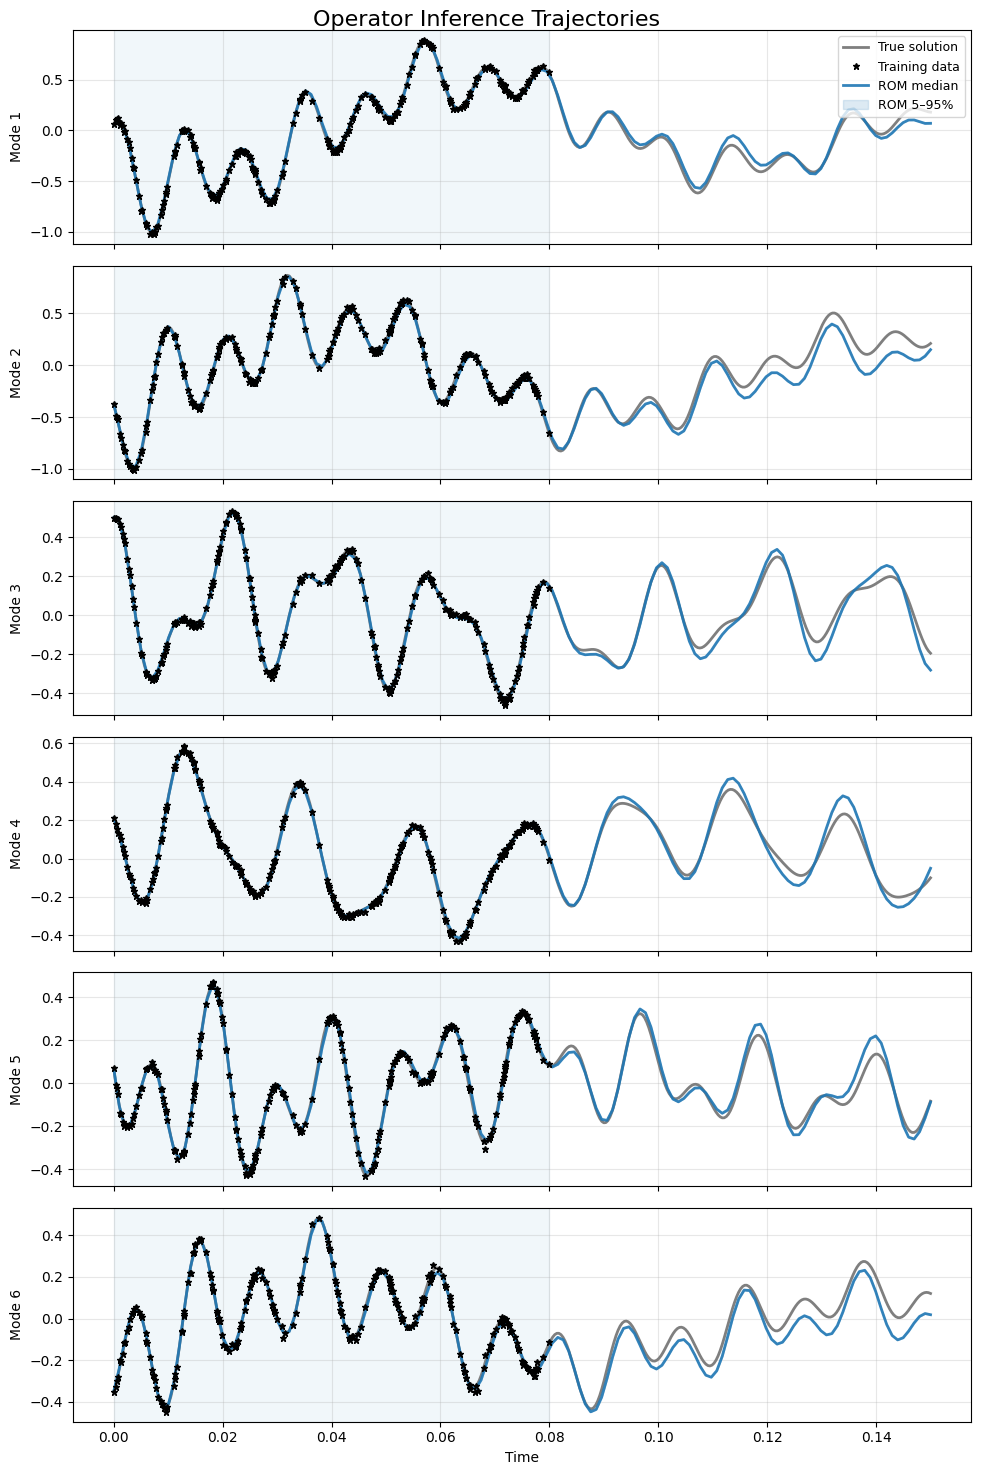

In [17]:
# Single-column view: ROM fit vs training data and true solution
plotter.operator_plot(
    q0=snapshots_comp_sampled[:, 0], 
    operator_samples=Os,
    latent_state_samples=latent_state_samples,
    rom=rom,
    figsize=(10, 2.5 * NUM_MODES),
    max_num_samples=200,
    plot_single=True,
    training_span=TRAINING_SPAN,
)
plt.show()

Stable ROM solves on prediction domain: 200


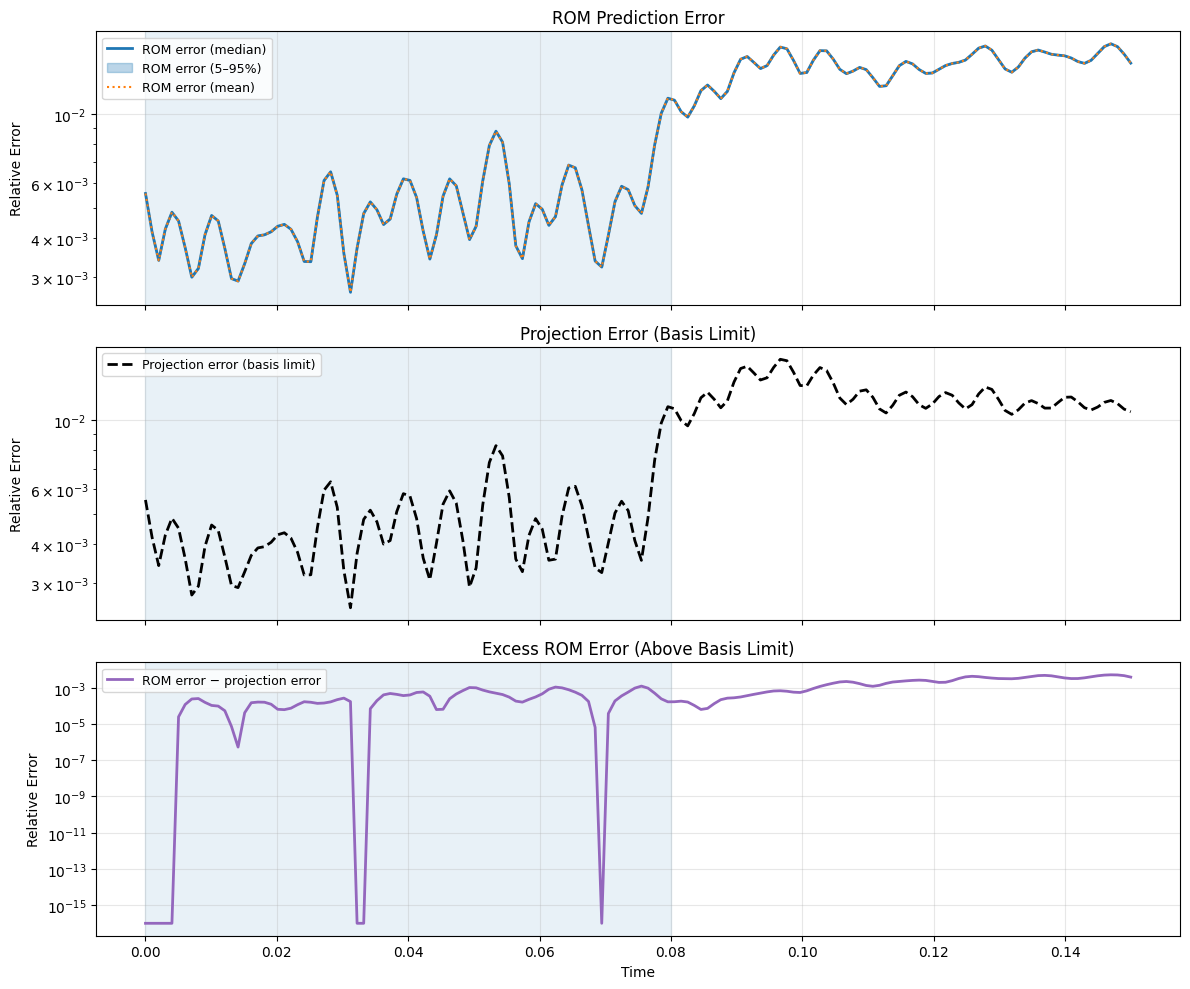

In [18]:
# Full order prediction error over time
# Generate ROM solves on prediction domain for error analysis
rom_solves_prediction = []
q0 = snapshots_comp_sampled[:, 0]
for O in Os:
    rom.model._extract_operators(O)
    rom.model.predict(state0=q0, t=time_domain_eval_prediction)
    if rom.model.predict_result_.y.shape[1] == len(time_domain_eval_prediction):
        rom_solves_prediction.append(rom.model.predict_result_.y)
rom_solves_prediction = np.array(rom_solves_prediction)
print(f"Stable ROM solves on prediction domain: {len(rom_solves_prediction)}")

# Compare ROM predictions to projection error baseline (3 separate subplots)
fig, axes = plot_full_order_error(
    rom_solves=rom_solves_prediction,
    basis=basis,
    true_states=true_states,
    time_domain_full=time_domain_full,
    time_domain_eval=time_domain_eval_prediction,
    training_span=TRAINING_SPAN,
    error_type='relative',
    figsize=(12, 10),
)
plt.show()

## 7. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** — highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** — low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** — checks if data is actually informing the posterior
- **Trace plots** — visual check for mixing and stationarity
- **Divergences & R-hat** — MCMC-specific convergence checks (when applicable)

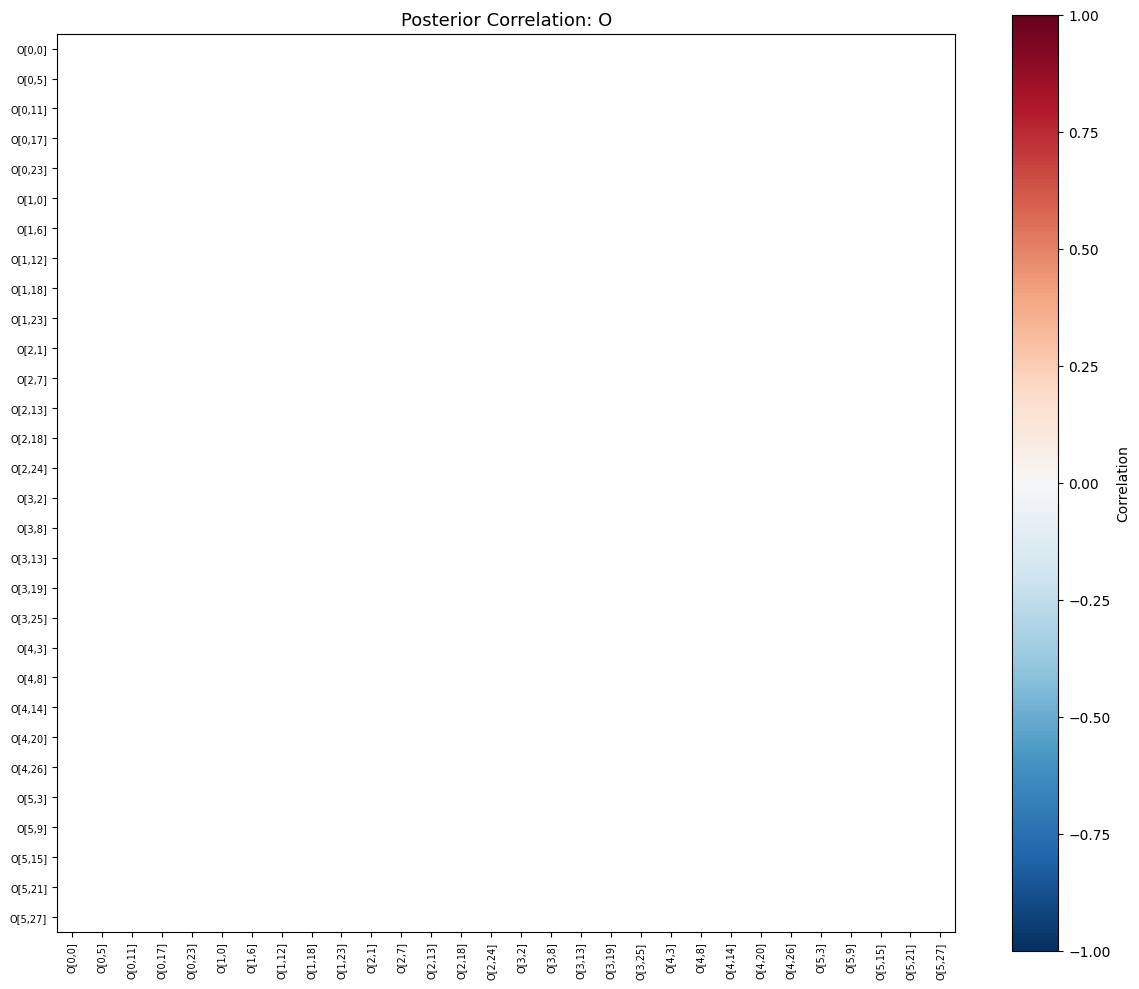

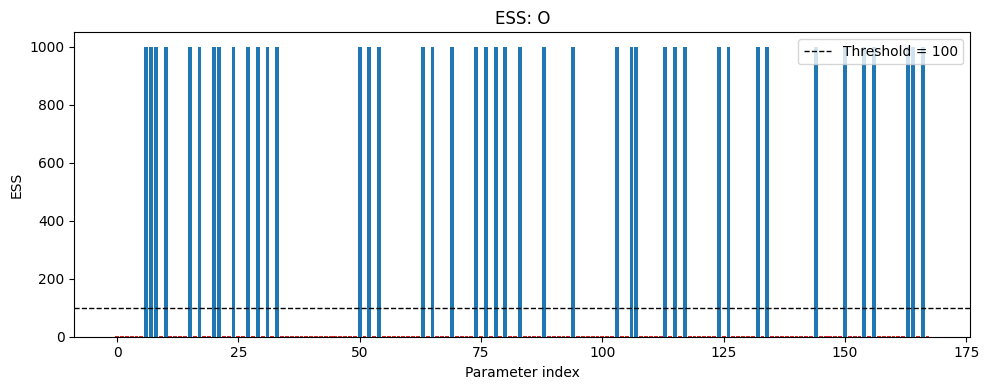

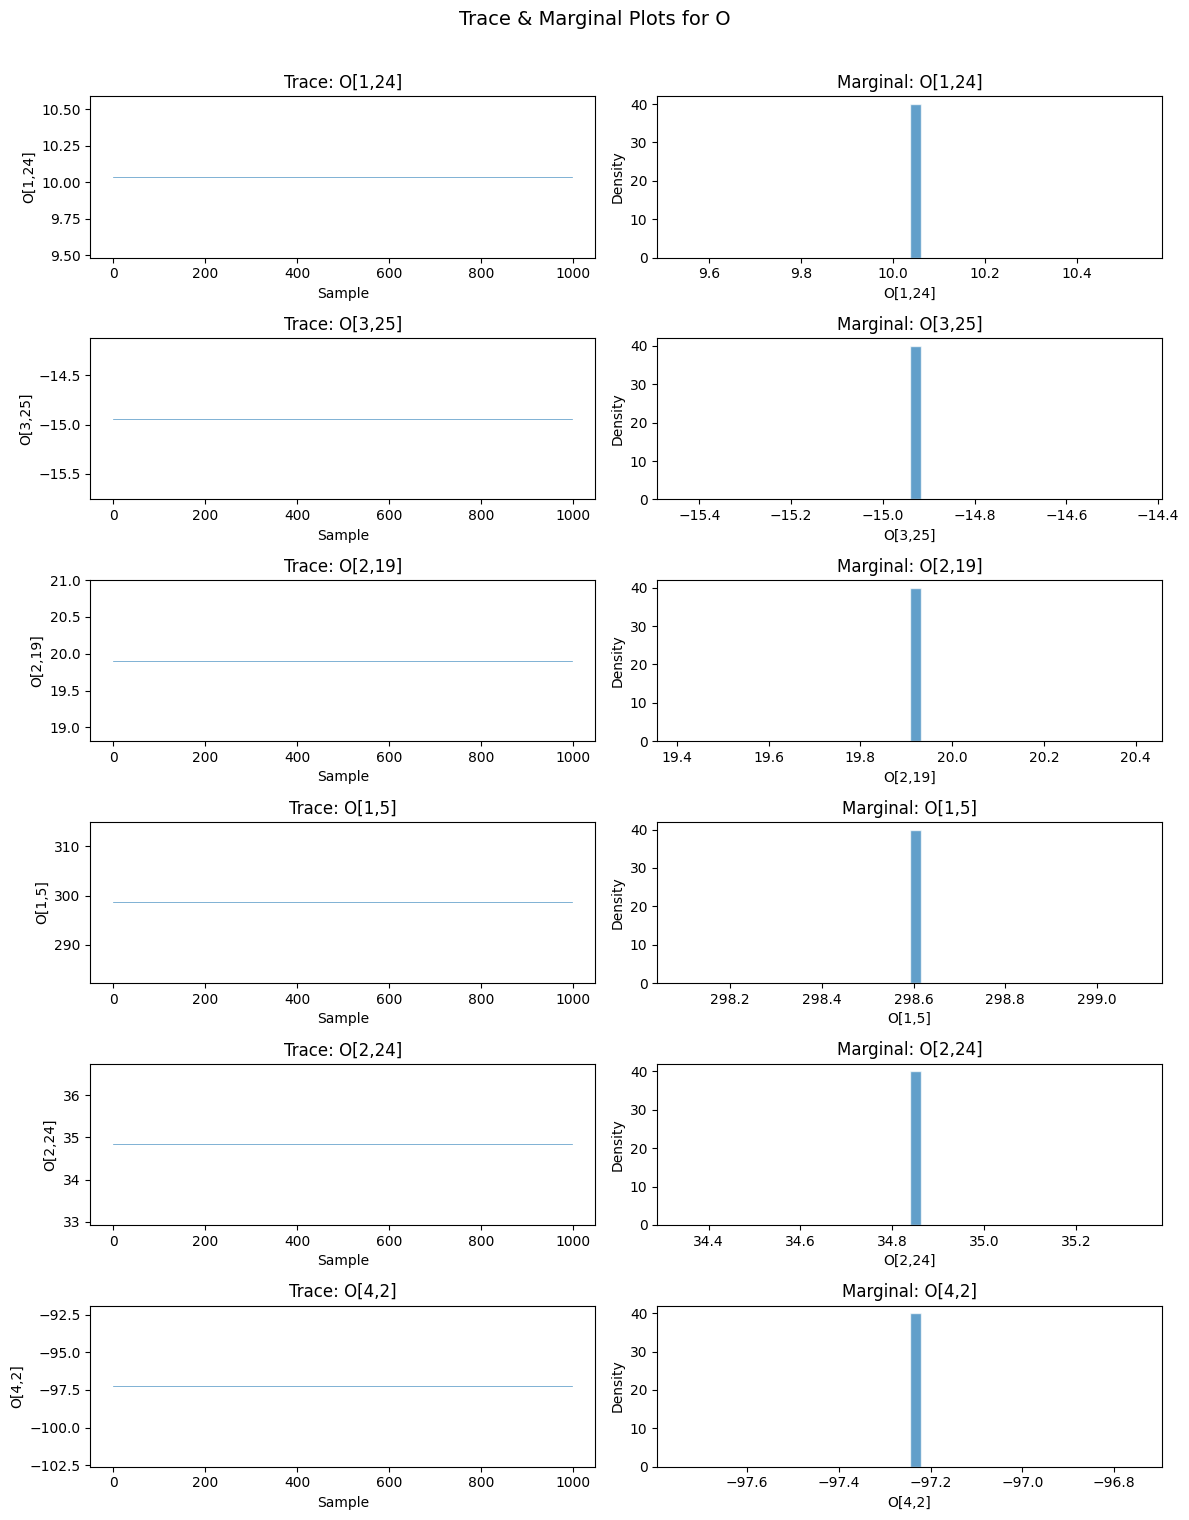

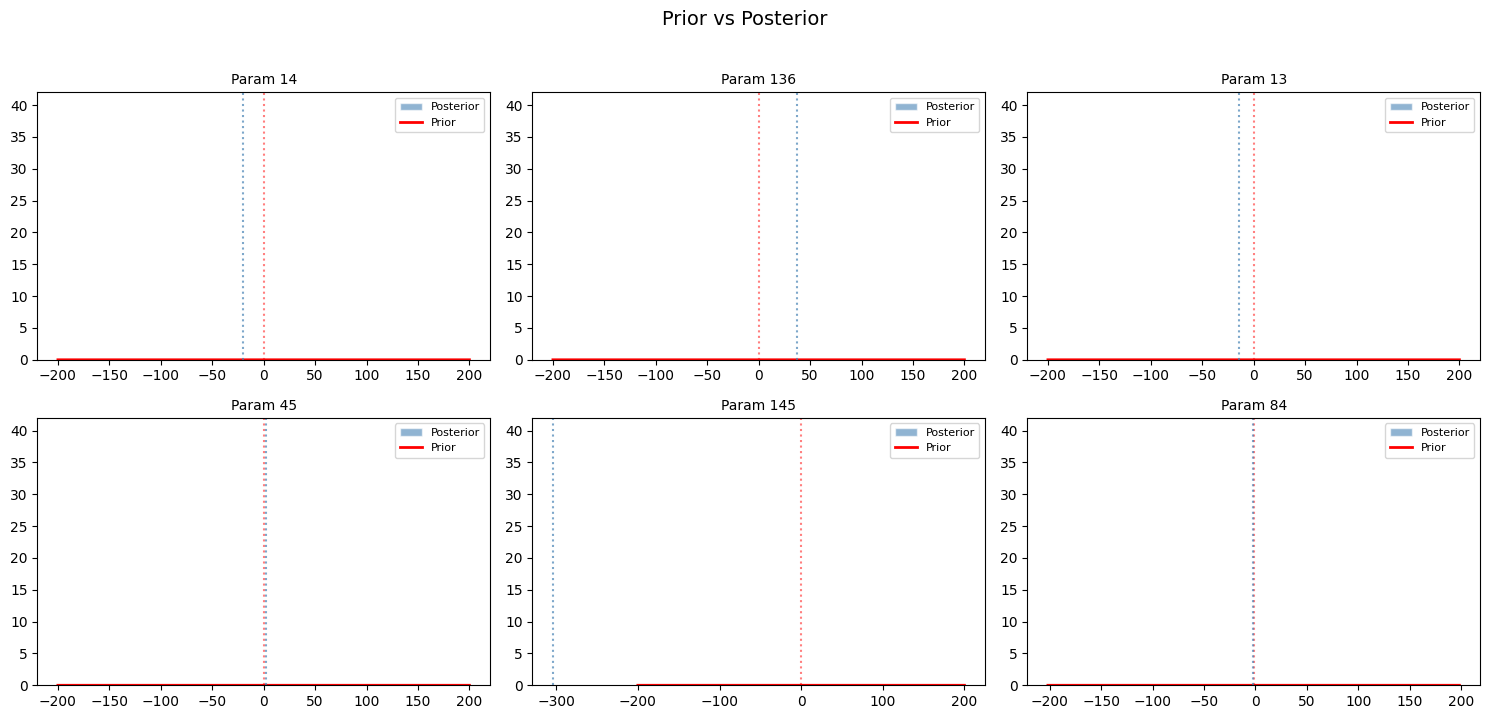

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  No high correlations detected (|r| > 0.9).

--- Effective Sample Size (ESS) ---
  Min ESS:  1.0
  Mean ESS: 256.7
  Max ESS:  1000.0
    O[0,0]: ESS = 1.0
    O[0,1]: ESS = 1.0
    O[0,2]: ESS = 1.0
    O[0,3]: ESS = 1.0
    O[0,4]: ESS = 1.0

--- Prior-Posterior Overlap ---
  O[1,7]: overlap = 3.18% [CHECK]
  O[2,16]: overlap = 3.21% [CHECK]
  O[3,1]: overlap = 2.75% [CHECK]
  O[2,1]: overlap = 3.22% [CHECK]
  O[5,13]: overlap = 2.87% [CHECK]

--- Summary Warnings ---
  1. 125 parameters have ESS < 100. Consider running longer chains or reparameterizing.
  2. Prior-posterior overlap for O[1,7] is 3% — prior may be misspecified (too narrow or wrong location).
  3. Prior-posterior overlap for O[2,16] is 3% — prior may be misspecified (too narrow or wrong location).
  4. Prior-posterior overlap for O[3,1] is 3% — prior may be misspecified (too narrow or wrong location).
  5. Prior-posterior overlap for O[2,1] is 3% — pri

In [19]:
# Run full diagnostic suite
# Pass mcmc_result if MCMC was used, otherwise None
diag_report = run_diagnostics(
    samples=samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=mcmc_result if RUN_MCMC else None,
    samples_by_chain=None,  # Set to per-chain sample dicts if using multi-chain MCMC
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=True,
    plot=True,
)